Imports

In [2]:
import pandas as pd
import random as rd
from PIL import Image
import urllib.request
import matplotlib.pyplot as plt
import os

Functions

In [5]:
# Function to remove artists that only appear once
def remove_single_occurrence_artists(data):
    # Count the occurrences of each artist
    artist_counts = data['artist'].value_counts()
    
    # Filter artists that appear more than once
    artists_to_keep = artist_counts[artist_counts > 1].index
    
    # Keep only rows where the artist is in the list of artists to keep
    filtered_data = data[data['artist'].isin(artists_to_keep)]
    
    return filtered_data

# Function for picking and asking
def questioner(data):
    rounds = 1
    tolerance = 0.1 # answer is correct if within this set %
    rand_number = rd.randint(0, len(data)-1)
    price = data.price.loc[rand_number]
    url = data.source.loc[rand_number]
    file = data.source.loc[rand_number].split('/')[-1]
    urllib.request.urlretrieve(url, file) 
    art = Image.open(file)    
    plt.imshow(art)
    plt.axis('off')
    plt.show(block=False)  # Show the image without blocking the code
       
    while rounds <= 6:

        if rounds == 2:
            print('The art is called:', data.name.loc[rand_number])
        elif rounds == 3:
            print('The artist is:', data.country.loc[rand_number])
        elif rounds == 4:
            if pd.isna(data.yearOfDeath.loc[rand_number]):
                print('The artist is alive')
            else:
                print('The artist died in:', data.yearOfDeath.loc[rand_number])
        elif rounds == 5:
            print('The artist is:', data.artist.loc[rand_number])
        elif rounds == 6:
            artist_prices = data[data['artist'] == data.artist.loc[rand_number]].price
            artist_other = artist_prices[artist_prices != price].sample(n=1).values[0]
            print('Other art by this artist has sold for: $' + str(artist_other))

        answer = input('How much is this art worth?')
        try:
            answer = float(answer)
        except ValueError:
            answer = 0
        print('Your answer: $' + str(answer))

        if answer == price:
            print('You are right')
            break
        elif price * (1 - tolerance) <= answer <= price * (1 + tolerance):
            print('You are within ' + str(100 * tolerance) + '%')
            print('The exact price was $' + str(price))
            break
        elif answer > price:
            print('Too High', '\n')
        elif answer < price:
            print('Too low', '\n')
        else:
            pass
        
        rounds += 1

    else:
        print('Out of rounds')
        print('The answer was $' + str(price))
    plt.close()
    os.remove(file)  # Delete the downloaded image file

Data

In [6]:
# Load data
useful_cols = ['artist', 'country', 'yearOfBirth', 'yearOfDeath', 'name', 'year',
               'price', 'material', 'height', 'width', 'link', 'source']
art_df = remove_single_occurrence_artists(pd.read_csv('data.txt', sep='\t', usecols=useful_cols))

/var/folders/qf/50pg87pd01j43ph2cn3wl0sw0000gn/T/ipykernel_3512/1661362201.py:4: DtypeWarning: Columns (3,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  art_df = remove_single_occurrence_artists(pd.read_csv('data.txt', sep='\t', usecols=useful_cols))


Game

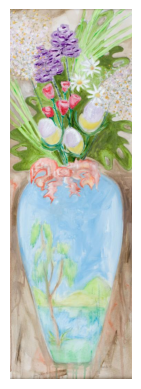

Your answer: $400.0
Too low 

The art is called: Mrs Thompson's vase
Your answer: $2000.0
Too High 

The artist is: Irish
Your answer: $1000.0
Too High 

The artist is alive
Your answer: $800.0
You are within 10.0%
The exact price was $782.0


In [7]:
questioner(art_df)